# **Rough Baseline on Final Merged Data Before Data Pre-Processing**

**Import packages and data**

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Missing data visualization
import missingno as msno

# Plotting
import matplotlib.pyplot as plt

# Model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score)

In [4]:
df = pd.read_csv("final_merged.csv")
df.head()

,patientunitstayid,gender,age,ethnicity,admissionheight,admissionweight,unittype,bmi,dialysis,wbc,...,hospitaldischargestatus,unitdischargestatus,unitvisitnumber,visitnumber,readmit,ICU_death,hospital_death,ICU_readmit,readmit_clean,bad_outcome
0,141764,Female,87.0,Caucasian,157.5,NaN,Med-Surg ICU,NaN,NaN,NaN,...,Alive,Alive,2,NaN,NaN,0,0,1,0,1
1,141765,Female,87.0,Caucasian,157.5,46.5,Med-Surg ICU,18.745276,0.0,10.2,...,Alive,Alive,1,1.0,0.0,0,0,0,0,0
2,143870,Male,76.0,Caucasian,167.0,77.5,SICU,27.788734,0.0,11.7,...,Alive,Alive,1,1.0,0.0,0,0,0,0,0
3,144815,Female,34.0,Caucasian,172.7,60.3,Med-Surg ICU,20.217741,0.0,7.9,...,Alive,Alive,1,1.0,0.0,0,0,0,0,0
4,145427,Male,61.0,Caucasian,177.8,91.7,SICU,29.007201,0.0,21.1,...,Alive,Alive,1,1.0,0.0,0,0,0,0,0


**Check out missingness from DataFrame**

<Axes: >

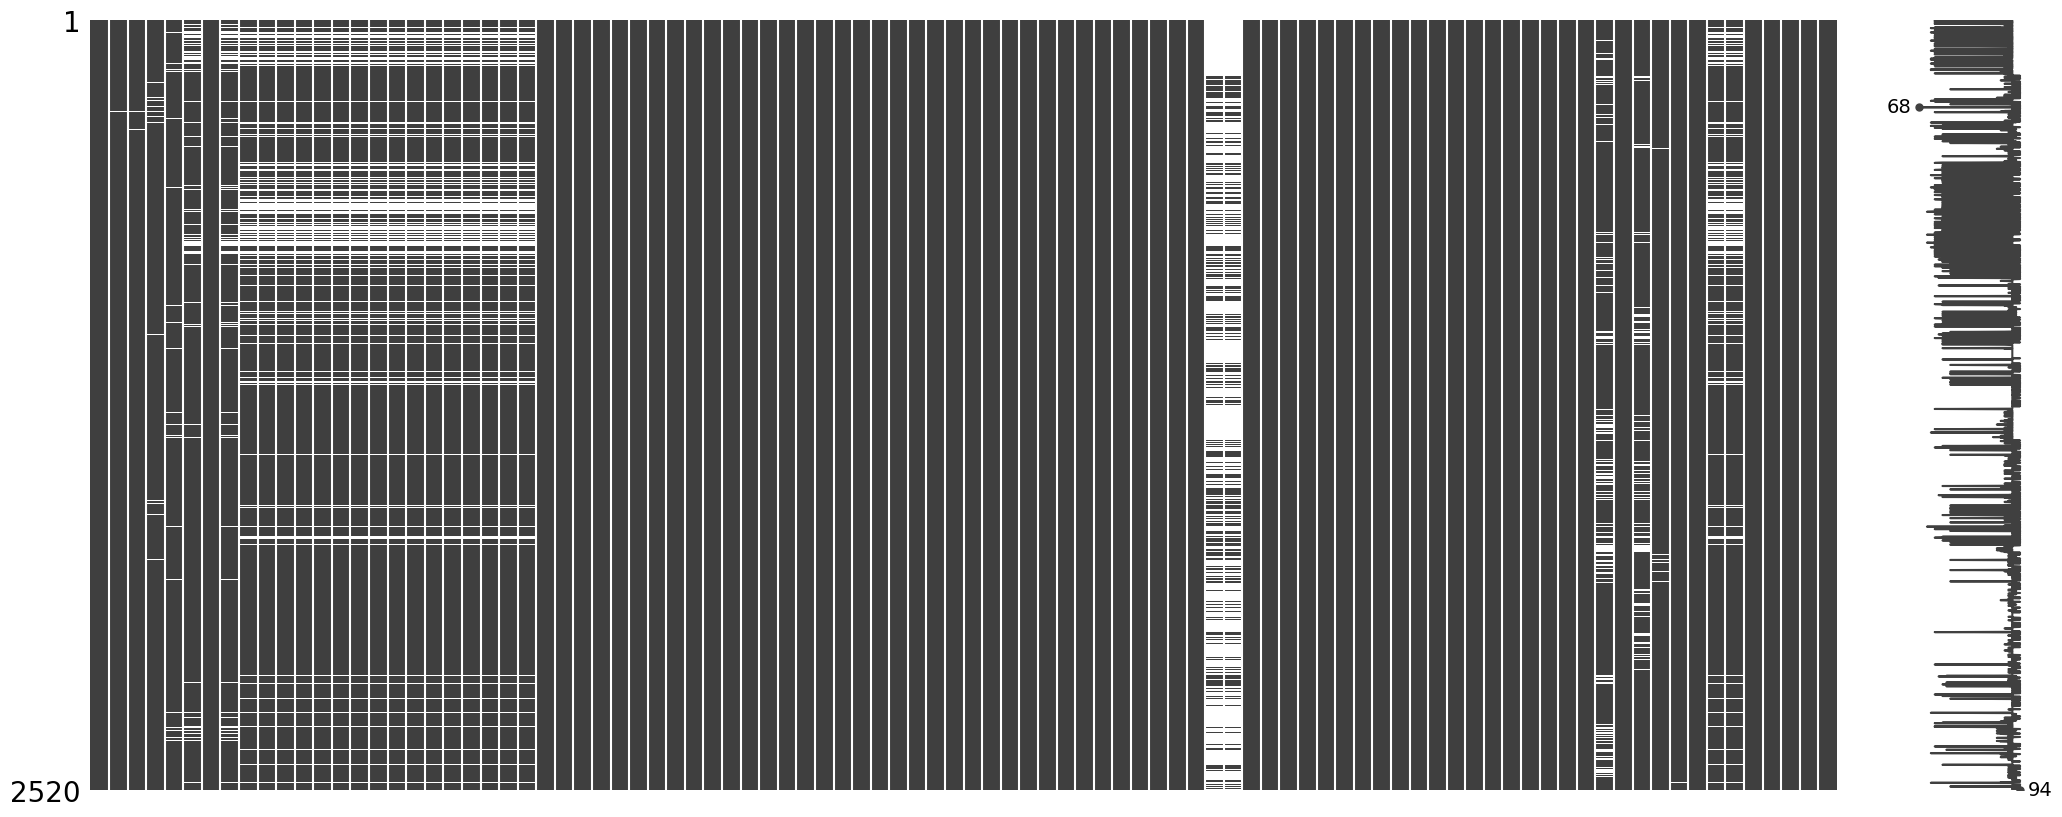

In [5]:
# Output the missingness matrix visualization
msno.matrix(df)

In [6]:
# Calculate missing percentage for each column
missing_props = df.isnull().mean()
missing_summary = (df.isnull().mean() * 100).sort_values(ascending=False)

# Filter columns with > 20% missing
cols_to_drop = missing_props[missing_props > 0.20].index.tolist()
print(f"Columns with > 20% missing: {cols_to_drop}")
print(missing_summary[missing_summary > 20])

Columns with > 20% missing: ['drug_allergy', 'non_drug_allergy']
non_drug_allergy    69.285714
drug_allergy        69.285714
dtype: float64


In [7]:
# See unique values for any feature

unique_values= df["hx_immuno"].unique()
print(unique_values)

[0. 1.]


**Inspect data**

In [8]:
df.columns

Index(['patientunitstayid', 'gender', 'age', 'ethnicity', 'admissionheight',
       'admissionweight', 'unittype', 'bmi', 'dialysis', 'wbc',
       'respiratoryrate', 'sodium', 'heartrate', 'meanbp', 'ph', 'hematocrit',
       'creatinine', 'albumin', 'pao2', 'pco2', 'bun', 'glucose', 'bilirubin',
       'fio2', 'aps_missing', 'acutephysiologyscore', 'apachescore',
       'apache_missing', 'aids', 'hepaticfailure', 'lymphoma',
       'metastaticcancer', 'leukemia', 'immunosuppression', 'cirrhosis',
       'diabetes', 'midur', 'pred_missing', 'total_diagnoses', 'primary_count',
       'major_count', 'other_count', 'primary_ratio', 'major_ratio',
       'pasthistoryvalue', 'hx_cardio', 'hx_respiratory', 'hx_neuro',
       'hx_cancer', 'hx_renal', 'hx_liver', 'hx_endocrine', 'hx_immuno',
       'hx_heme', 'hx_none', 'intaketotal_x', 'outputtotal_x',
       'dialysistotal_x', 'nettotal_x', 'io_missing_x', 'drug_allergy',
       'non_drug_allergy', 'hospitalid_x', 'temp_min', 'temp_max', 'h

**Things to note:**
- there are same variables (hospitalid_x, hospitalid_y) - compare to see if they are the same, then remove one
- remove the other target features
    - hospitaldischargestatus, unitdischargestatus, unitvisitnumber, visitnumber, readmit, ICU_death, hospital_death, ICU_readmit, readmit_clean
- take note of ID and features that will not be put in the model
    - patientunitstayid, hospitalid 
- make sure each feature is the appropriate variable type

In [9]:
# Compare and drop whether columns are identical (ignoring missing values)
df = df.drop(columns=[col for col in df.columns if col.endswith('_y')])
df = df.rename(columns=lambda x: x.replace('_x', '') if x.endswith('_x') else x)

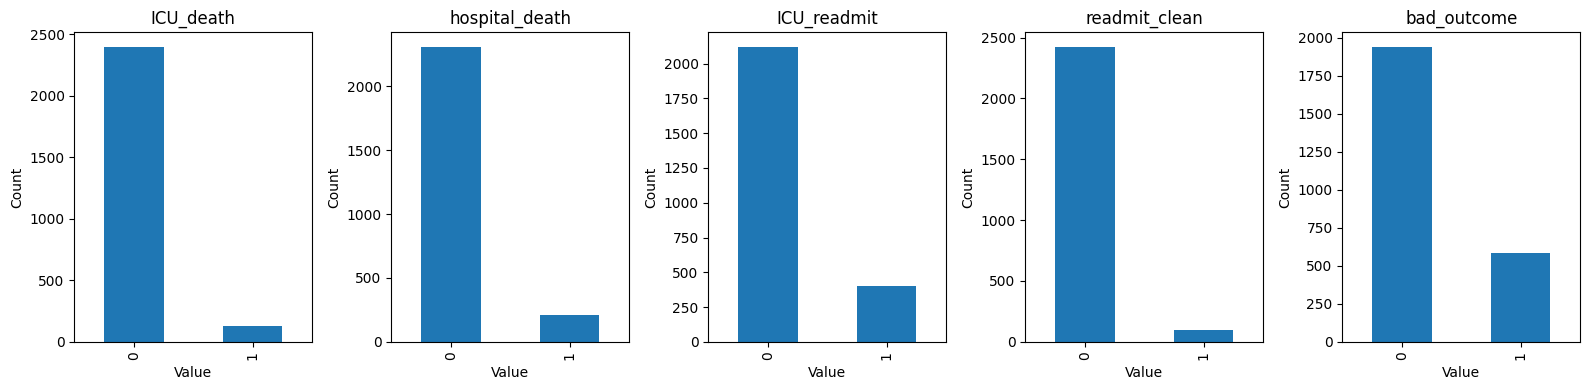

In [10]:
cols = ['ICU_death', 'hospital_death', 'ICU_readmit', 'readmit_clean', 'bad_outcome']

fig, axes = plt.subplots(1, len(cols), figsize=(16, 4))

for i, col in enumerate(cols):
    df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=axes[i],
        title=col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
# Drop the repeating target feature names and any other unecessary ones
df = df.drop(columns=[col for col in df.columns if col.endswith('_y')])
df = df.drop(columns=['ICU_death','hospital_death','ICU_readmit','readmit_clean', 'hospitaldischargestatus', 'unitdischargestatus', 
                     'unitvisitnumber', 'visitnumber', 'readmit', 'pasthistoryvalue', 'hospitalid'])

# Change teachingstatus from t/f to 1/0
df['teachingstatus'] = df['teachingstatus'].map({'t': 1, 'f': 0})

In [12]:
# Check if variables are the appropriate type 
dtype_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'missing_%': df.isnull().mean().values * 100})

pd.set_option('display.max_rows', None) # displays the full table
pd.set_option('display.max_columns', None)

dtype_summary.sort_values(by='dtype')

TypeError: '<' not supported between instances of 'StringDtype' and 'numpy.dtypes.Int64DType'

1. **Binary features**
- vitals_missing, io_missing, pred_missing, apache_missing, aps_missing, bad_outcome, dialysis, hx_cardio, hx_respiratory, hx_neuro, hx_cancer, hx_renal, hx_liver, hx_endocrine, hx_immuno, hx_heme, hx_none, drug_allergy, non_drug_allergy, immunosuppression, midur, diabetes, cirrhosis, leukemia, metastaticcancer, hepaticfailure, aids, lymphoma, teachingstatus
2. **ID features**
- patientunitstayid
3. **Categorical features**
- gender: female, male, nan
- ethnicity: caucasian, hispanic, asian, african american, nan, native american, other/unknown
- unittype: med-surg icu, sicu, micu, cticu, neuro icu, ccu-cticu, cardiac icu, cscicu
- numbedscategory: <100, 100-249, nan, >=500, 250-499
- region: midwest, nan, south, west, northeast

In [13]:
# See unique values for any feature

unique_values= df["region"].unique()
print(unique_values)

<StringArray>
['Midwest', nan, 'South', 'West', 'Northeast']
Length: 5, dtype: str


In [14]:
# Change binary columns to the correct type
binary_cols = [
    'vitals_missing', 'io_missing', 'pred_missing', 'apache_missing',
    'aps_missing', 'bad_outcome', 'dialysis', 'hx_cardio',
    'hx_respiratory', 'hx_neuro', 'hx_cancer', 'hx_renal',
    'hx_liver', 'hx_endocrine', 'hx_immuno', 'hx_heme', 'hx_none',
    'drug_allergy', 'non_drug_allergy', 'immunosuppression', 'midur',
    'diabetes', 'cirrhosis', 'leukemia', 'metastaticcancer',
    'hepaticfailure', 'aids', 'lymphoma', 'teachingstatus']

df[binary_cols] = df[binary_cols].replace({
    't': 1, 'true': 1, 'yes': 1,
    'f': 0, 'false': 0, 'no': 0})

df[binary_cols] = df[binary_cols].astype(float).astype('Int64')

In [15]:
# Save it
df.to_csv("final_merged_cleaned.csv", index=False)

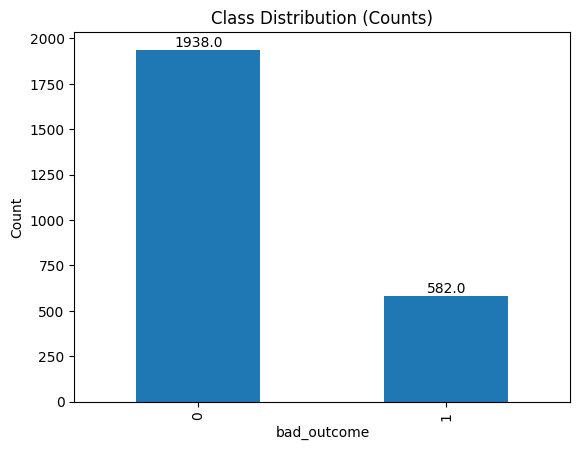

In [16]:
ax = df['bad_outcome'].value_counts().plot(kind='bar')

# add labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom')

plt.title("Class Distribution (Counts)")
plt.xlabel("bad_outcome")
plt.ylabel("Count")
plt.show()

**Perform rough baseline**

In [17]:
df.shape

(2520, 77)

In [18]:
target = 'bad_outcome'

y = df[target]
X = df.drop(columns=[target, 'patientunitstayid'])

In [19]:
binary_cols = [
    'vitals_missing', 'io_missing', 'pred_missing', 'apache_missing',
    'aps_missing', 'dialysis', 'hx_cardio', 'hx_respiratory', 'hx_neuro',
    'hx_cancer', 'hx_renal', 'hx_liver', 'hx_endocrine', 'hx_immuno',
    'hx_heme', 'hx_none', 'drug_allergy', 'non_drug_allergy',
    'immunosuppression', 'midur', 'diabetes', 'cirrhosis',
    'leukemia', 'metastaticcancer', 'hepaticfailure', 'aids',
    'lymphoma', 'teachingstatus']

df[binary_cols] = df[binary_cols].astype(float)

cat_cols = [
    'gender', 'ethnicity', 'unittype',
    'numbedscategory', 'region']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [21]:
numeric_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

In [22]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=3000))])

model.fit(X_train, y_train)

/Users/marielle/jupyter_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90       388
         1.0       0.70      0.47      0.56       116

    accuracy                           0.83       504
   macro avg       0.78      0.71      0.73       504
weighted avg       0.82      0.83      0.82       504

ROC-AUC: 0.8395618556701031
PR-AUC: 0.6817968367583804


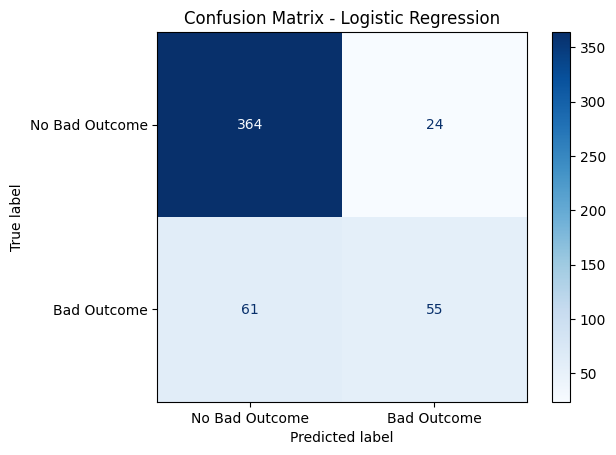

In [24]:
# Output a confusion matrix to see performance
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Bad Outcome", "Bad Outcome"],
    cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

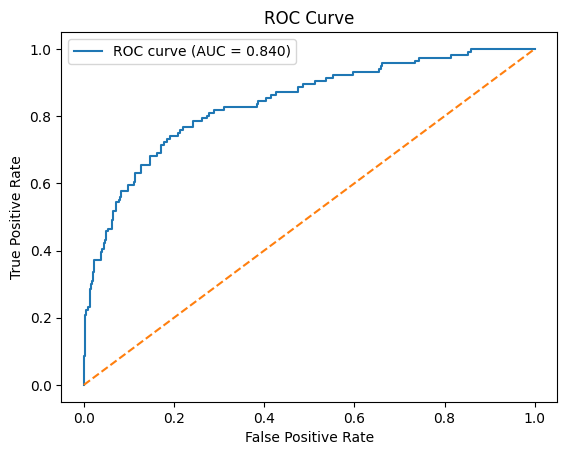

In [25]:
# ROC-curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

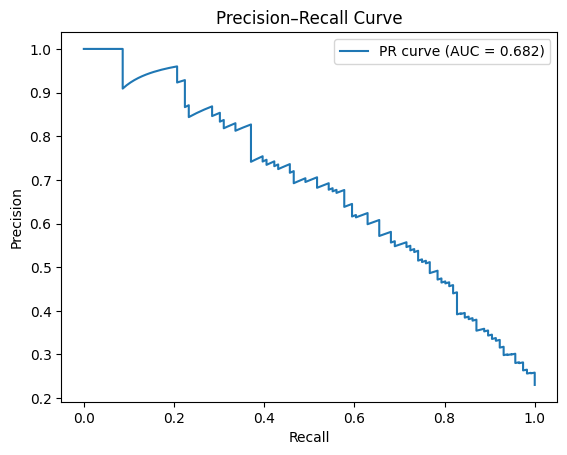

In [26]:
# PR-AUC curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

| Class / Metric           | Precision | Recall | F1-score | Support |
| ------------------------ | --------- | ------ | -------- | ------- |
| **0.0 (No bad outcome)** | 0.86      | 0.94   | 0.90     | 388     |
| **1.0 (Bad outcome)**    | 0.72      | 0.49   | 0.58     | 116     |
|                          |           |        |          |         |
| **Accuracy**             |           |        | 0.84     | 504     |
| **Macro Avg**            | 0.79      | 0.72   | 0.74     | 504     |
| **Weighted Avg**         | 0.83      | 0.84   | 0.83     | 504     |


| Metric  | Value |
| ------- | ----- |
| ROC-AUC | 0.844 |
| PR-AUC  | 0.684 |
